In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
AC_stark_vals=[-0.3065898535663432]
AC_stark_vals_ef=[-2.206589853566343]
A_vals=[12.060132973240993]

## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_params(f_d,f_supp,A,evolution,f_rabi,AC_stark_d,AC_stark_supp,lims,scales,verbose=True):

    #Rajat AC-stark siirtymälle
    min_range_d = lims[0][0]
    max_range_d = lims[0][1]

    min_range_supp = lims[1][0]
    max_range_supp = lims[1][1]
    
    e_data=[]
    f_data=[]
    
    AC_stark_vals_d=np.arange(min_range_d,max_range_d)/scales[0]+AC_stark_d
    AC_stark_vals_supp=np.arange(min_range_supp,max_range_supp)/scales[1]+AC_stark_supp
    
    for i in range(min_range_d,max_range_d):
        delta_d=AC_stark_d+i/scales[0]
        
        max_e_vals=[]
        max_f_vals=[]
        
        for j in range(min_range_supp,max_range_supp):

            delta_supp=AC_stark_supp+j/scales[1] #AC-stark siirtymä
    
            sim_vals = pulses.sim_3_part_pulses(f_d+delta_d,f_supp+delta_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,drag=True,use_avg=True)
    
            max_e_vals.append(sim_vals[0])
            max_f_vals.append(sim_vals[1])

        e_data.append(max_e_vals)
        f_data.append(max_f_vals)

    xtick_locs=np.arange(0,1, step=0.2)*len(AC_stark_vals_d)
    ytick_locs=np.arange(0,1, step=0.2)*len(AC_stark_vals_supp)

    xlabels=[round(AC_stark_vals_d[int(i)],3) for i in xtick_locs]
    ylabels=[round(AC_stark_vals_supp[int(i)],3) for i in ytick_locs]

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(e_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_d-ω_q")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_supp-ω_ef")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="e-tason suurin todennäköisyys")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(f_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_d-ω_q")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_supp-ω_ef")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="f-tason suurin todennäköisyys")
    plt.show()

    if verbose:
        print(e_data)
        print(f_data)

    e_means = [np.mean(arr) for arr in e_data]
    e_index = np.argmax(e_means)
    f_index = np.argmin(f_data[e_index])
    
    delta_d=AC_stark_vals_d[e_index]
    delta_supp=AC_stark_vals_supp[f_index]
    
    return(delta_d,delta_supp)

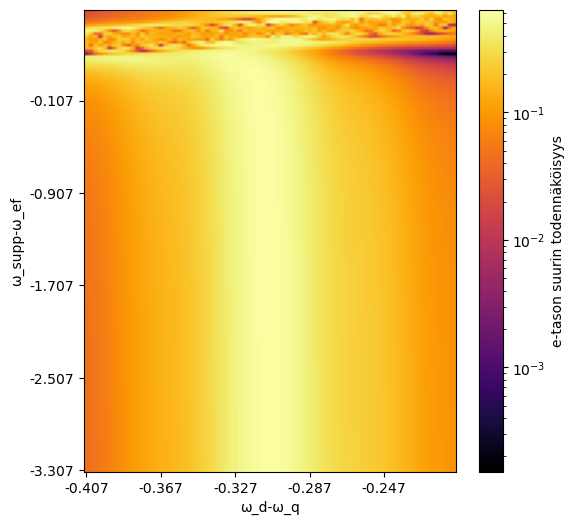

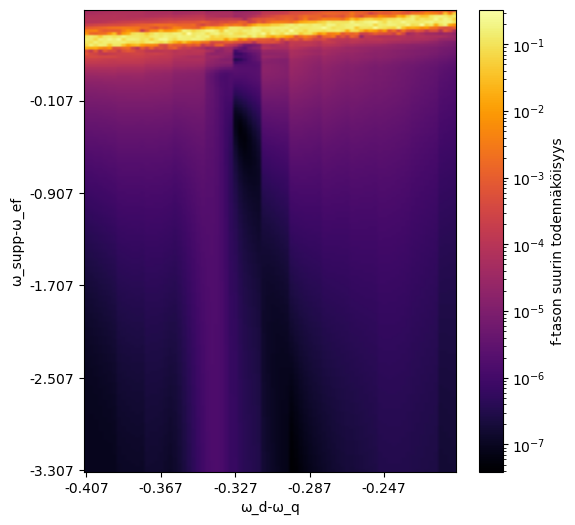

[[np.float64(0.044360298102888836), np.float64(0.044391022715406646), np.float64(0.0444221945865271), np.float64(0.04445382354023322), np.float64(0.04448591968996405), np.float64(0.044518493449340224), np.float64(0.044551555543369294), np.float64(0.04458511702016427), np.float64(0.04461918926317914), np.float64(0.04465378400401989), np.float64(0.04468891333583633), np.float64(0.04472458972734031), np.float64(0.04476082603748023), np.float64(0.044797635530806054), np.float64(0.044835031893567905), np.float64(0.04487302925058531), np.float64(0.0449116421829312), np.float64(0.044950885746480276), np.float64(0.04499077549136146), np.float64(0.04503132748238104), np.float64(0.04507255832046399), np.float64(0.04511448516517127), np.float64(0.04515712575836124), np.float64(0.04520049844906431), np.float64(0.04524462221964348), np.float64(0.045289516713309594), np.float64(0.0453352022630879), np.float64(0.04538169992232007), np.float64(0.04542903149679456), np.float64(0.04547721957860812), np.

Amplitudi (GHz): 12.060132973240993
Ajotaajuus AC Stark (GHz): -0.3090898535663432
Hiljennetty taajuus AC Stark (GHz): -2.206589853566343
E-tason suurin todennäköisyys: 0.9982015592286373
F-tason suurin todennäköisyys: 2.875019431092543e-07


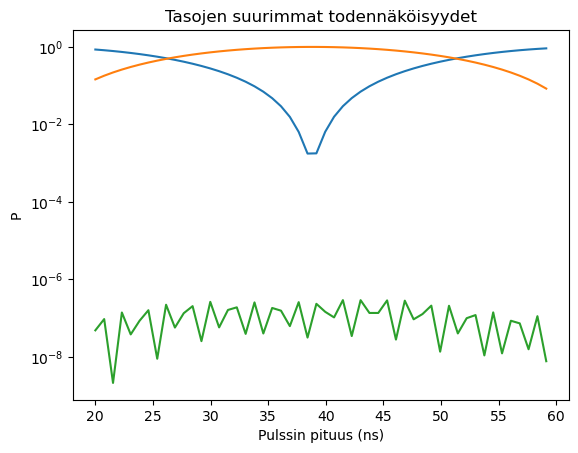

---------------------------------------------


In [7]:
f_d=qubit.frequency/3
f_supp=f_ef/3
A=A_vals[0]
f_rabi=2*np.pi/40

AC_stark_vals_d=[]
AC_stark_vals_supp=[]

params=find_params(f_d,f_supp,A,evolution_eigenbasis,f_rabi,AC_stark_vals[0],AC_stark_vals[0],[[-40,40],[-120,40]],[400,40])
AC_stark_vals_d.append(params[0])
AC_stark_vals_supp.append(params[1])

m=1

vals = pulses.sim_3_part_pulses(f_d+AC_stark_vals_d[-1],f_supp+AC_stark_vals_supp[-1],A,evolution_eigenbasis,dim,f_rabi/m,t_ramp=10,U_f=1,drag=True)

print("Amplitudi (GHz):", A)

print("Ajotaajuus AC Stark (GHz):", AC_stark_vals_d[-1])
print("Hiljennetty taajuus AC Stark (GHz):", AC_stark_vals_supp[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

Amplitudi (GHz): 12.060132973240993
Ajotaajuus AC Stark (GHz): -0.3065898535663432
E-tason suurin todennäköisyys: 0.9998168137577784
F-tason suurin todennäköisyys: 6.531356641425047e-07


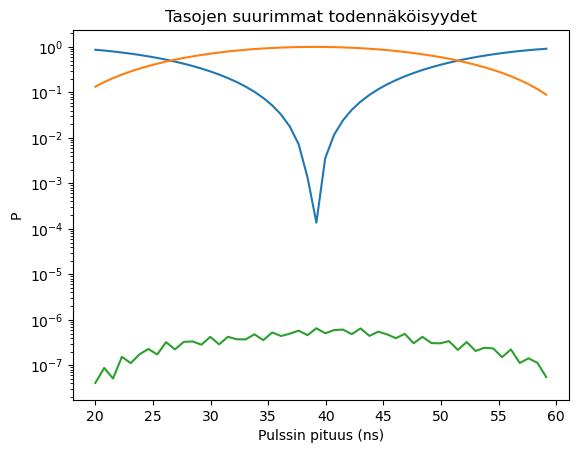

---------------------------------------------


In [12]:
m=1

f_d=qubit.frequency/3
f_supp=f_ef/3
A=A_vals[0]
f_rabi=2*np.pi/40

vals = pulses.sim_3_part_pulses(f_d+AC_stark_vals[-1],f_supp+AC_stark_vals[-1],A,evolution_eigenbasis,dim,f_rabi/m,t_ramp=10,U_f=1,drag=False)

print("Amplitudi (GHz):", A)

print("Ajotaajuus AC Stark (GHz):", AC_stark_vals[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")